# Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import category_encoders as ce

excel_file = "Crash Risk Data (1).xls"

# Load the data
df = pd.read_excel(excel_file)
df.head()

,gvkey,fyear,sic,big4,modified,lnmarket_val,lntotal_assets,asset_growth,liability_growth,sales_growth,...,lit,z_score,netfilesize,n_words_den3,n_negative_den3,n_positive_den3,n_uncertainty_den3,n_litigious_den3,crash_new320Plus,ncskew_new_plus
0,10884,1993,100,1,0,6.324117,7.915988,-0.048556,-0.030367,-0.069889,...,0,1.341682,450656,60503,563,226,405,1883,0,-0.760525
1,10390,1994,100,1,1,5.025090,3.804883,-0.042524,-0.235625,-0.082085,...,0,13.269255,190514,20653,244,108,180,457,0,-0.774498
2,8596,1994,100,1,1,7.898852,7.133631,0.026246,-0.063346,0.100678,...,0,7.983232,91626,10501,88,133,104,63,0,0.290179
3,2812,1994,100,0,0,7.221101,8.255486,0.136002,0.220105,0.119820,...,0,1.861746,415553,51758,584,321,520,1466,0,-0.855944
4,14881,1994,100,1,1,5.130932,5.765191,0.008217,-0.024667,0.097770,...,0,2.181140,362277,48629,659,430,281,1499,0,-0.140956


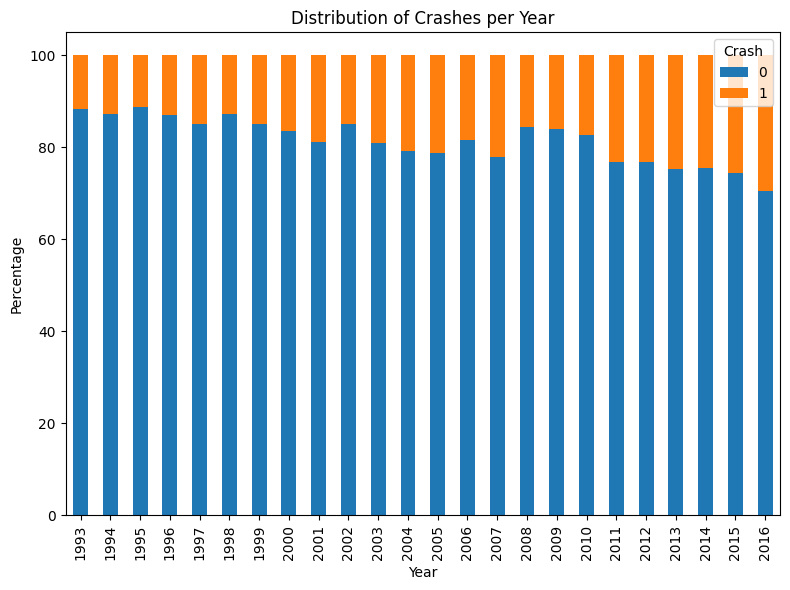

In [2]:
counts = df.groupby('fyear')['crash_new320Plus'].value_counts(normalize=True).mul(100).unstack()

# Plot a stacked bar chart
counts.plot(kind='bar', stacked=True, figsize=(8, 6))

# Labeling the plot
plt.title('Distribution of Crashes per Year')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.legend(title='Crash')
plt.tight_layout()
plt.show()

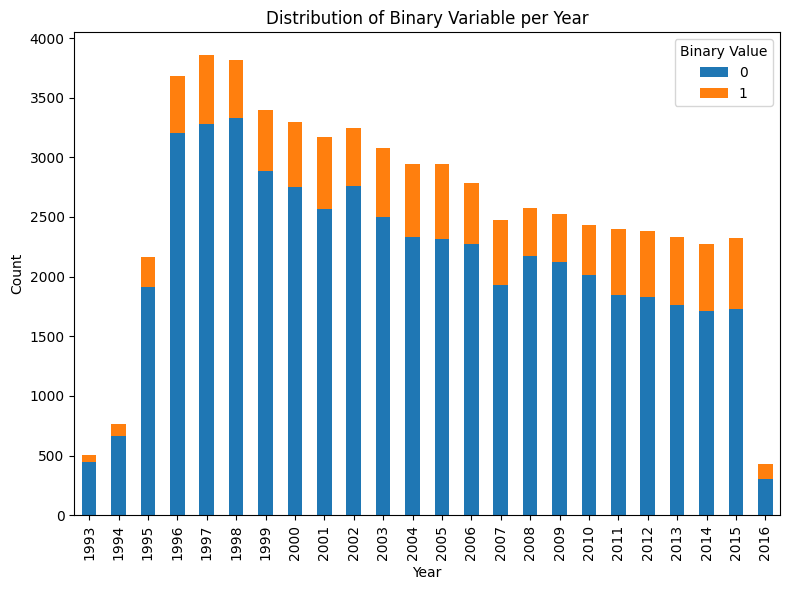

In [3]:
counts = df.groupby('fyear')['crash_new320Plus'].value_counts().unstack()

# Plot a stacked bar chart
counts.plot(kind='bar', stacked=True, figsize=(8, 6))

# Labeling the plot
plt.title('Distribution of Binary Variable per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Binary Value')
plt.tight_layout()
plt.show()

# Transform Data

In [4]:
# Split to train test (we do not use "ncskew_new_plus")
X = df[['gvkey', 'fyear', 'sic', 'big4', 'modified', 'lnmarket_val',
       'lntotal_assets', 'asset_growth', 'liability_growth', 'sales_growth',
       'mtb_at', 'roa2', 'lev_mkt', 'age', 'lit', 'z_score', 'netfilesize',
       'n_words_den3', 'n_negative_den3', 'n_positive_den3',
       'n_uncertainty_den3', 'n_litigious_den3']]
y = df['crash_new320Plus']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)

In [5]:
counts = X_train['sic'].value_counts()
rare_categories = counts[counts < 11].index
print(rare_categories)
# Create an 'Other' category for the rare categories.
X_train['sic'] = X_train['sic'].apply(
    lambda x: 'Other' if x in rare_categories else x
)
X_test['sic'] = X_test['sic'].apply(
    lambda x: 'Other' if x in rare_categories else x
)
# Create a mean embedding for sic.
enc = ce.TargetEncoder(cols=['sic']).fit(X_train, y_train)
X_train = enc.transform(X_train)
X_test = enc.transform(X_test)

Index([3360, 3250, 4013, 3444, 6513, 7385, 6510, 3334, 6797, 4822, 3433, 6159,
       5960, 7600, 3910, 7320, 2600, 2340, 4220, 4610,  200, 3822, 5082, 1221,
       4961, 2673, 6162, 7384, 3695, 5020, 3524, 7000, 2092, 6361, 3960, 5099,
       8600],
      dtype='int64', name='sic')


In [6]:
# Standardise
scaler = StandardScaler()

categories_to_standardise = ['gvkey', 'fyear', 'sic', 'lnmarket_val',
       'lntotal_assets', 'asset_growth', 'liability_growth', 'sales_growth',
       'mtb_at', 'roa2', 'lev_mkt', 'age', 'z_score', 'netfilesize',
       'n_words_den3', 'n_negative_den3', 'n_positive_den3',
       'n_uncertainty_den3', 'n_litigious_den3']

X_train[categories_to_standardise] = scaler.fit_transform(X_train[categories_to_standardise])
X_test[categories_to_standardise] = scaler.transform(X_test[categories_to_standardise])


In [7]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

def upsampled_kfold(x, y, params, clf):
    pipeline = Pipeline([
        ('oversample', RandomOverSampler(random_state=42)),
        ('classifier', clf)
    ])    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=params,
                           cv=cv,
                           scoring='f1')
    grid_search.fit(x, y)
    results = grid_search.cv_results_

    # Print the mean and standard deviation F1 scores along with parameters
    for mean_score, std_score, params in zip(results['mean_test_score'], 
                                            results['std_test_score'], 
                                            results['params']):
        print(f"Params: {params} - Mean F1: {mean_score:.4f} (+/- {std_score:.4f})")
    return grid_search

In [8]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc

def evaluate(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    conf = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = conf.ravel()
    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    f1 = f1_score(y_true, y_pred, average=None)
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    area = auc(fpr, tpr)
    print(f"The accuracy is: {acc:.4f}")
    print(f"The F1 score is: {np.round(f1,4)}")
    print(f"AUC is: {area:.4f}")
    print(f"The sensitivity is {sensitivity:.4f}")
    print(f"The specificity is {specificity:.4f}")
    print(f"The confusion matrix is: \n {conf}")

# Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

params = {'classifier__C':[0.001, 0.01, 0.1, 1],
          'classifier__tol':[1e-5, 1e-4, 1e-3]}
clf = LogisticRegression(random_state=42, solver='newton-cholesky')
model = upsampled_kfold(X_train, y_train, params, clf)

Params: {'classifier__C': 0.001, 'classifier__tol': 1e-05} - Mean F1: 0.3496 (+/- 0.0031)
Params: {'classifier__C': 0.001, 'classifier__tol': 0.0001} - Mean F1: 0.3496 (+/- 0.0031)
Params: {'classifier__C': 0.001, 'classifier__tol': 0.001} - Mean F1: 0.3496 (+/- 0.0031)
Params: {'classifier__C': 0.01, 'classifier__tol': 1e-05} - Mean F1: 0.3508 (+/- 0.0032)
Params: {'classifier__C': 0.01, 'classifier__tol': 0.0001} - Mean F1: 0.3509 (+/- 0.0033)
Params: {'classifier__C': 0.01, 'classifier__tol': 0.001} - Mean F1: 0.3512 (+/- 0.0034)
Params: {'classifier__C': 0.1, 'classifier__tol': 1e-05} - Mean F1: 0.3510 (+/- 0.0037)
Params: {'classifier__C': 0.1, 'classifier__tol': 0.0001} - Mean F1: 0.3508 (+/- 0.0036)
Params: {'classifier__C': 0.1, 'classifier__tol': 0.001} - Mean F1: 0.3514 (+/- 0.0032)
Params: {'classifier__C': 1, 'classifier__tol': 1e-05} - Mean F1: 0.3511 (+/- 0.0033)
Params: {'classifier__C': 1, 'classifier__tol': 0.0001} - Mean F1: 0.3511 (+/- 0.0034)
Params: {'classifier__C

In [15]:
clf_preds = model.predict(X_test)
evaluate(y_test, clf_preds)

The accuracy is: 0.5997
The F1 score is: [0.7132 0.3373]
AUC is: 0.5917
The sensitivity is 0.5794
The specificity is 0.6040
The confusion matrix is: 
 [[6153 4034]
 [ 914 1259]]


# Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

params = {'classifier__n_estimators':[100, 200],
          'classifier__max_depth':[10, 20, 30],
          'classifier__min_samples_split':[2, 5],
          'classifier__min_samples_leaf': [1, 2]
}  
clf = RandomForestClassifier(random_state=42)         
model = upsampled_kfold(X_train, y_train, params, clf)

Params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100} - Mean F1: 0.3572 (+/- 0.0049)
Params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200} - Mean F1: 0.3568 (+/- 0.0064)
Params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100} - Mean F1: 0.3574 (+/- 0.0065)
Params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200} - Mean F1: 0.3569 (+/- 0.0059)
Params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100} - Mean F1: 0.3578 (+/- 0.0055)
Params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators'

In [18]:
clf_preds = model.predict(X_test)
evaluate(y_test, clf_preds)

The accuracy is: 0.6278
The F1 score is: [0.7409 0.339 ]
AUC is: 0.5944
The sensitivity is 0.5430
The specificity is 0.6458
The confusion matrix is: 
 [[6579 3608]
 [ 993 1180]]


# Neural Network

In [ ]:
from sklearn.neural_network import MLPClassifier

params = {'classifier__hidden_layer_sizes': [(64,), (64, 64, 64, 64, 64, 64, 64, 64)],
          'classifier__activation': ['relu', 'tanh'],
          'classifier__learning_rate_init': [0.001, 0.01, 0.1],
            }  
clf = MLPClassifier(random_state=42, max_iter=300)         
model = upsampled_kfold(X_train, y_train, params, clf)

In [21]:
clf_preds = model.predict(X_test)
evaluate(y_test, clf_preds)

The accuracy is: 0.6103
The F1 score is: [0.7255 0.3283]
AUC is: 0.5833
The sensitivity is 0.5416
The specificity is 0.6249
The confusion matrix is: 
 [[6366 3821]
 [ 996 1177]]


In [26]:
from sklearn.neural_network import MLPClassifier

params = {'classifier__hidden_layer_sizes': [(64, 64, 64, 64, 64, 64, 64, 64)],
          'classifier__activation': ['relu'],
          'classifier__learning_rate_init': [0.01],
          'classifier__alpha':[0.0001, 0.001, 0.01, 0.1, 1.0]
            }  
clf = MLPClassifier(random_state=42, max_iter=300)         
model = upsampled_kfold(X_train, y_train, params, clf)

Params: {'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (64, 64, 64, 64, 64, 64, 64, 64), 'classifier__learning_rate_init': 0.01} - Mean F1: 0.3201 (+/- 0.0185)
Params: {'classifier__activation': 'relu', 'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (64, 64, 64, 64, 64, 64, 64, 64), 'classifier__learning_rate_init': 0.01} - Mean F1: 0.3169 (+/- 0.0081)
Params: {'classifier__activation': 'relu', 'classifier__alpha': 0.01, 'classifier__hidden_layer_sizes': (64, 64, 64, 64, 64, 64, 64, 64), 'classifier__learning_rate_init': 0.01} - Mean F1: 0.3394 (+/- 0.0057)
Params: {'classifier__activation': 'relu', 'classifier__alpha': 0.1, 'classifier__hidden_layer_sizes': (64, 64, 64, 64, 64, 64, 64, 64), 'classifier__learning_rate_init': 0.01} - Mean F1: 0.3568 (+/- 0.0029)
Params: {'classifier__activation': 'relu', 'classifier__alpha': 1.0, 'classifier__hidden_layer_sizes': (64, 64, 64, 64, 64, 64, 64, 64), 'classifier__learning_rat

In [27]:
clf_preds = model.predict(X_test)
evaluate(y_test, clf_preds)

The accuracy is: 0.5735
The F1 score is: [0.6843 0.3426]
AUC is: 0.5966
The sensitivity is 0.6323
The specificity is 0.5609
The confusion matrix is: 
 [[5714 4473]
 [ 799 1374]]


In [9]:
from sklearn.neural_network import MLPClassifier

params = {'classifier__hidden_layer_sizes': [(64)],
          'classifier__activation': ['relu'],
          'classifier__learning_rate_init': [0.01],
          'classifier__alpha':[0.0001, 0.001, 0.01, 0.1, 1.0]
            }  
clf = MLPClassifier(random_state=42, max_iter=300)         
model = upsampled_kfold(X_train, y_train, params, clf)

Params: {'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': 64, 'classifier__learning_rate_init': 0.01} - Mean F1: 0.3404 (+/- 0.0025)
Params: {'classifier__activation': 'relu', 'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': 64, 'classifier__learning_rate_init': 0.01} - Mean F1: 0.3433 (+/- 0.0023)
Params: {'classifier__activation': 'relu', 'classifier__alpha': 0.01, 'classifier__hidden_layer_sizes': 64, 'classifier__learning_rate_init': 0.01} - Mean F1: 0.3508 (+/- 0.0036)
Params: {'classifier__activation': 'relu', 'classifier__alpha': 0.1, 'classifier__hidden_layer_sizes': 64, 'classifier__learning_rate_init': 0.01} - Mean F1: 0.3558 (+/- 0.0035)
Params: {'classifier__activation': 'relu', 'classifier__alpha': 1.0, 'classifier__hidden_layer_sizes': 64, 'classifier__learning_rate_init': 0.01} - Mean F1: 0.3554 (+/- 0.0036)


In [10]:
clf_preds = model.predict(X_test)
evaluate(y_test, clf_preds)

The accuracy is: 0.5627
The F1 score is: [0.6725 0.3421]
AUC is: 0.5957
The sensitivity is 0.6466
The specificity is 0.5448
The confusion matrix is: 
 [[5550 4637]
 [ 768 1405]]
